In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
# Import required libraries

import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# --- DATA CLEANING ---
# 1. Drop the customerID column
df = df.drop('customerID', axis=1)

# 2. Convert 'TotalCharges' from text to numbers.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Check how many missing values we just created
print("Missing values before dropping:")
print(df.isnull().sum())

# 4. Drop the rows with missing values (usually only about 11 rows in this dataset)
df = df.dropna()

# 5. Show the final structure of our clean data
print("\nData cleaned! Here is the new structure:")
df.info()

Missing values before dropping:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Data cleaned! Here is the new structure:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService     

### 📊 Baseline Churn & The Impact of Contract Length
The visualizations below establish our starting point. The first chart displays the overall proportion of customers who have canceled their service versus those who stayed, allowing us to see the baseline churn rate of the dataset. The second chart breaks this churn down by the customer's contract type.

* **Business Insight:** Customers on **month-to-month plans** exhibit a massively higher churn rate compared to those on 1-year or 2-year commitments. The lack of a binding contract makes it incredibly easy for these users to leave. This clearly dictates that migrating month-to-month users to long-term contracts (perhaps through targeted discounts) should be a primary retention strategy.

/tmp/ipykernel_536/654184080.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2', ax=axes[0])


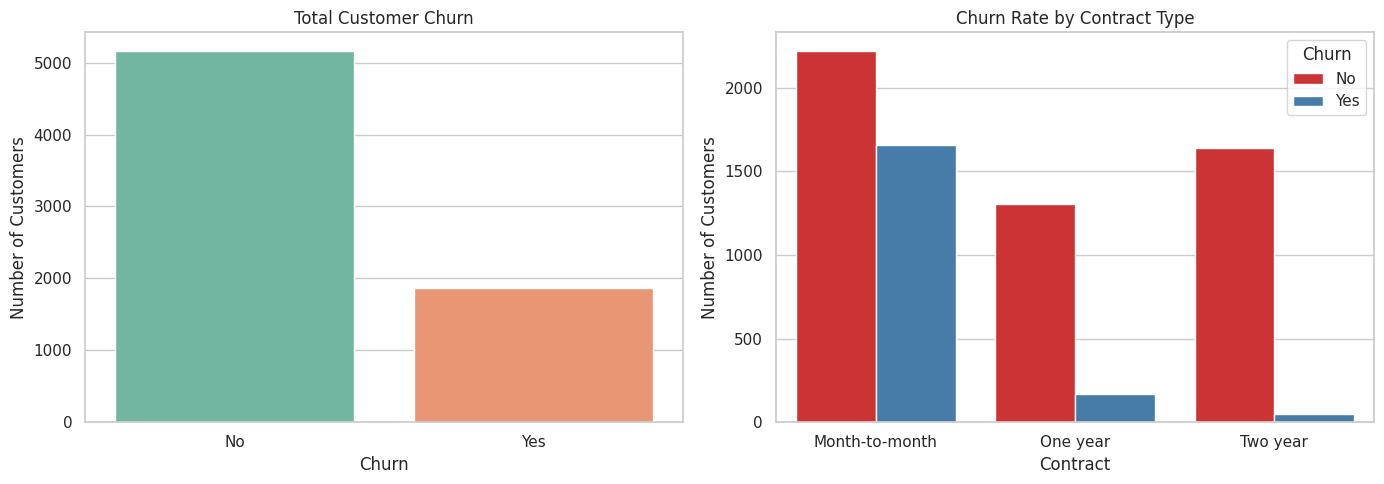

In [4]:
# --- EXPLORATORY DATA ANALYSIS (EDA) ---

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fig 1 & 2: Overall Churn vs. Contract Type

sns.countplot(data=df, x='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Total Customer Churn')
axes[0].set_ylabel('Number of Customers')

sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1', ax=axes[1])
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_ylabel('Number of Customers')

# Display the charts
plt.tight_layout()
plt.show()

### 💰 Financial & Lifespan Impact: Monthly Charges and Tenure
These boxplots illustrate how a customer's monthly bill and their overall lifespan with the company affect their decision to leave. Boxplots are excellent for visualizing the median (the middle line in the box) and the general spread of the data.

* **Business Insight (Monthly Charges):** Customers who churn generally have notably higher median monthly charges compared to those who stay. This highlights strong price sensitivity; as the monthly bill increases, customers are much more likely to seek out cheaper competitor alternatives.
* **Business Insight (Tenure):** Churn is heavily concentrated among much newer customers (those with a lower median tenure). Once a customer survives the initial "danger zone" of the first few months, their loyalty solidifies and their likelihood of leaving drops significantly. This indicates that early-stage onboarding and targeted discounts in the first 6 months are crucial for long-term retention.

/tmp/ipykernel_536/4024481012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2', ax=axes[0])
/tmp/ipykernel_536/4024481012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Set1', ax=axes[1])


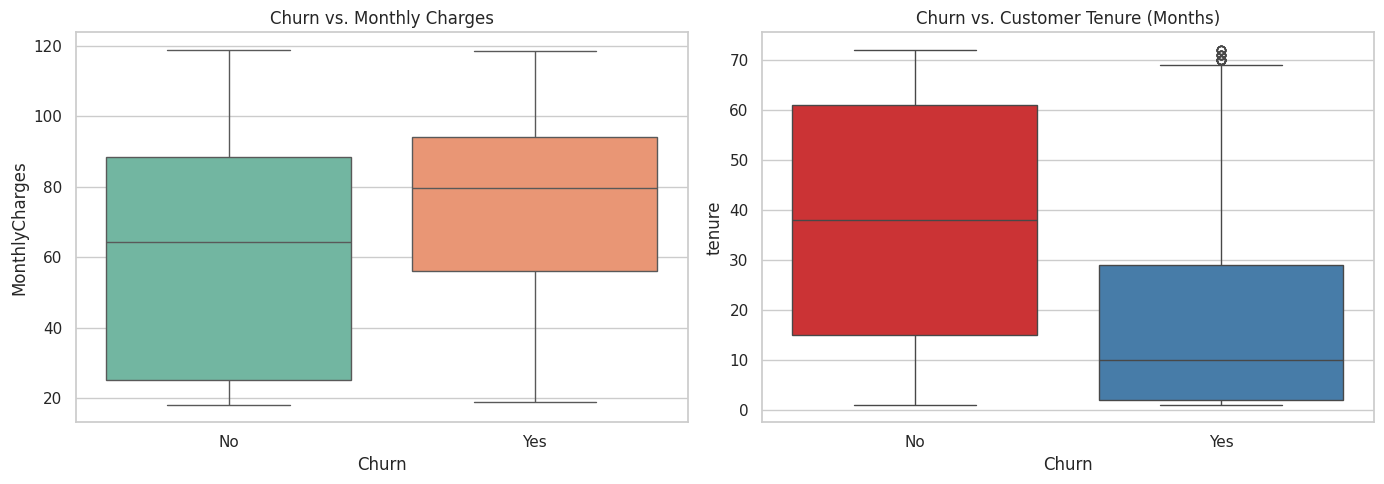

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2', ax=axes[0])
axes[0].set_title('Churn vs. Monthly Charges')

sns.boxplot(data=df, x='Churn', y='tenure', palette='Set1', ax=axes[1])
axes[1].set_title('Churn vs. Customer Tenure (Months)')

plt.tight_layout()
plt.show()

### 📡 Service Features: Internet Type & Tech Support
These charts analyze how a customer's specific service package and support features impact their likelihood of canceling.

* **Business Insight (Internet Service):** Customers with Fiber Optic internet typically churn at a significantly higher rate than those with DSL. Since Fiber Optic is usually the premium, most expensive tier, this high churn rate could indicate that the service is underperforming relative to its high price, or that competitors are heavily targeting this demographic.
* **Business Insight (Tech Support):** There is a massive disparity in churn between customers who have Tech Support and those who do not. Customers lacking Tech Support are far more likely to leave. This strongly suggests that technical frustration is a major churn driver, and bundling Tech Support into lower-tier packages could be a highly effective retention strategy.

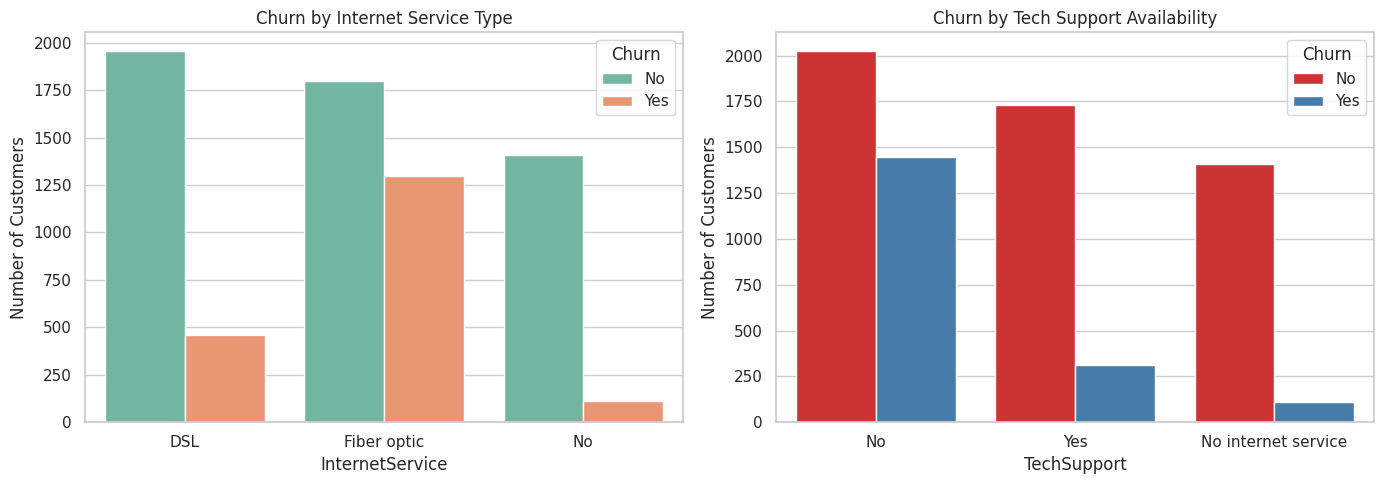

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- CHART 5: Churn by Internet Service Type ---
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Internet Service Type')
axes[0].set_ylabel('Number of Customers')

# --- CHART 6: Churn by Tech Support ---
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Set1', ax=axes[1])
axes[1].set_title('Churn by Tech Support Availability')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### 🔍 Heatmap Insights: What is this telling us?
This heatmap visualizes the linear correlation between our numerical variables.
* A score close to **1** indicates a strong positive relationship (as one goes up, the other goes up).
* A score close to **-1** indicates a strong negative relationship.
* **Key Takeaway:** Notice the relationship between `tenure` and `TotalCharges`. As expected, the longer a customer stays, the higher their total lifetime value. However, we must also look at how `MonthlyCharges` impacts churn in our categorical analysis below.

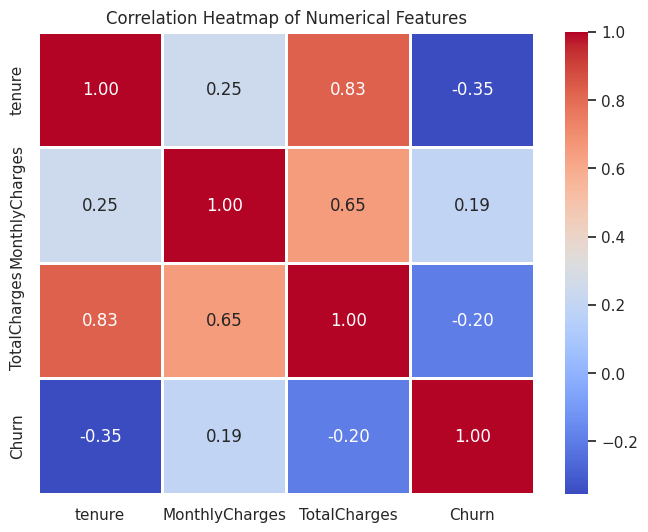

In [7]:
# Generate heatmap for numerical features

df_heat = df.copy()

df_heat['Churn'] = df_heat['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df_heat[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 🔬 Statistical Proof: Internet Service vs. Churn
While our visualizations strongly suggested that certain internet services (like Fiber Optic) have higher cancellation rates, we need to prove this mathematically rather than just relying on visuals.

We are using a **Chi-Square Test of Independence**. This statistical test is specifically designed to determine if there is a genuine, significant relationship between two categorical variables, or if the differences we see are just due to random chance.

* **The Objective:** To scientifically validate to stakeholders that the type of Internet Service a customer receives directly impacts their likelihood of churning. If the resulting P-value is less than 0.05, we have mathematical proof that the relationship is real.

In [8]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create a contingency table comparing Internet Service and Churn
contingency_table = pd.crosstab(df['InternetService'], df['Churn'])
print("Contingency Table:\n", contingency_table)
print("-" * 40)

# 2. Perform the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p:.4f}")

# 3. State the statistical conclusion
if p < 0.05:
    print("\n✅ Conclusion: The p-value is less than 0.05. There is a STATISTICALLY SIGNIFICANT relationship between the type of Internet Service a customer has and whether or not they Churn.")
else:
    print("\n❌ Conclusion: The p-value is greater than 0.05. There is NO significant relationship between Internet Service and Churn.")

Contingency Table:
 Churn              No   Yes
InternetService            
DSL              1957   459
Fiber optic      1799  1297
No               1407   113
----------------------------------------
Chi-Square Statistic: 728.70
P-value: 0.0000

✅ Conclusion: The p-value is less than 0.05. There is a STATISTICALLY SIGNIFICANT relationship between the type of Internet Service a customer has and whether or not they Churn.


### 🤖 Predictive Modeling: Forecasting Customer Churn


Now that we understand the historical drivers of churn, we can move from descriptive analytics to predictive analytics.

We are deploying a **Random Forest Classifier**, a highly robust machine learning algorithm. It works by building hundreds of individual "decision trees" based on our dataset and having them vote on the final outcome: whether a specific customer will leave or stay.

* **The Business Objective:** To build an automated early-warning system. By accurately identifying 'at-risk' customers *before* they hit the cancel button, the business can proactively dispatch targeted retention offers, directly protecting monthly recurring revenue.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Prepare the Data (Drop customerID as it has no predictive power)
if 'customerID' in df.columns:
    df_ml = df.drop('customerID', axis=1)
else:
    df_ml = df.copy()

# 2. Convert all text columns into numbers (One-Hot Encoding) so the ML model can read them
df_ml = pd.get_dummies(df_ml, drop_first=True)

# 3. Define our Features (X) and our Target (y)
# Note: pd.get_dummies likely renamed 'Churn' to 'Churn_Yes'
X = df_ml.drop('Churn_Yes', axis=1)
y = df_ml['Churn_Yes']

# 4. Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Build and Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. Make Predictions and Evaluate
y_pred = rf_model.predict(X_test)

print(f"🎯 Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred))

🎯 Model Accuracy: 78.54%

Detailed Classification Report:

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



### 📊 Machine Learning Conclusion
Our Random Forest predictive model achieved a **78.5% overall accuracy** in predicting customer churn based purely on the dataset features.

**Business Takeaways:**
* The model is highly accurate at identifying loyal customers who will stay (83% precision).
* **Future Optimization:** If the business goal is to aggressively catch *every* single person who might leave (even if it means a few false alarms), we could further tune this model using techniques like SMOTE (handling imbalanced data) or hyperparameter tuning to increase the recall score for churners.